# Soft-Constrained Benchmark Summary

Compare GCOPTER soft vs MIGHTY soft for jerk weight 1e-5.

In [7]:
# Load soft-constrained benchmark data
from pathlib import Path
import numpy as np
import pandas as pd

# Config
ROOT = Path('/media/kkondo/T7/mighty_gcopter_bench/simple_bench/weight_1e-5')

# Load data from bench_stats.csv for each goal
records = []
soft_dir = ROOT / 'soft'

for goal_dir in sorted(soft_dir.glob('goal_*')):
    bench_csv = goal_dir / 'bench_stats.csv'
    if not bench_csv.exists():
        continue
    try:
        df = pd.read_csv(bench_csv, on_bad_lines='skip')
        if len(df) == 0:
            continue
        row = df.iloc[-1]
        has_new = 'gc_pref_err' in df.columns
        records.append({
            'gc_solve_ms': row.get('gc_solve_ms', np.nan),
            'my_solve_ms': row.get('my_solve_ms', np.nan),
            'gc_travel_s': row.get('gc_time_s', np.nan),
            'my_travel_s': row.get('my_time_s', np.nan),
            'gc_pref_err': row.get('gc_pref_err', -1.0) if has_new else -1.0,
            'gc_vref_err': row.get('gc_vref_err', -1.0) if has_new else -1.0,
            'my_pref_err': row.get('my_pref_err', -1.0) if has_new else -1.0,
            'my_vref_err': row.get('my_vref_err', -1.0) if has_new else -1.0,
        })
    except Exception:
        continue

data = pd.DataFrame(records)
print(f"Loaded {len(data)} cases")

Loaded 100 cases


In [8]:
# Summary Table: Rows = Solver, Columns = Metrics (mean ± std)

# Filter valid pref/vref errors (>= 0, since -1 means disabled)
gc_pref = data['gc_pref_err'][data['gc_pref_err'] >= 0]
gc_vref = data['gc_vref_err'][data['gc_vref_err'] >= 0]
my_pref = data['my_pref_err'][data['my_pref_err'] >= 0]
my_vref = data['my_vref_err'][data['my_vref_err'] >= 0]

def fmt(vals):
    if len(vals) == 0:
        return "N/A"
    return f"{vals.mean():.4f} ± {vals.std():.4f}"

summary = pd.DataFrame({
    'pref_err (m)': [fmt(gc_pref), fmt(my_pref)],
    'vref_err (m/s)': [fmt(gc_vref), fmt(my_vref)],
    'travel_time (s)': [fmt(data['gc_travel_s']), fmt(data['my_travel_s'])],
    'solve_time (ms)': [fmt(data['gc_solve_ms']), fmt(data['my_solve_ms'])],
}, index=['GCOPTER soft', 'MIGHTY soft'])

print("=" * 80)
print(f"Summary: jerk_weight=1e-5, n={len(data)} cases")
print("=" * 80)
summary

Summary: jerk_weight=1e-5, n=100 cases


,pref_err (m),vref_err (m/s),travel_time (s),solve_time (ms)
GCOPTER soft,0.0171 ± 0.0227,1.0277 ± 0.1758,19.6956 ± 0.5682,7.4062 ± 5.9660
MIGHTY soft,0.0041 ± 0.0037,0.1577 ± 0.0199,14.7526 ± 1.5829,10.5772 ± 5.5062


In [9]:
# Add labels to RViz screenshot for paper figure
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from PIL import Image
import numpy as np
from pathlib import Path

class _GradientHandler(HandlerBase):
    """Legend handler to render a gradient bar instead of a solid patch."""
    def __init__(self, cmap):
        super().__init__()
        self.cmap = cmap

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        n = 50
        artists = []
        if self.cmap is not None:
            cmap = plt.cm.get_cmap(self.cmap)
            h = height / n
            for i in range(n):
                color = cmap(i / (n - 1))
                artists.append(Rectangle((xdescent, ydescent + i * h),
                                         width, h, transform=trans,
                                         facecolor=color, edgecolor='none'))
        return artists


def trim_add_legend_save(
    img_input,
    out_path,
    cut=(0, 0, 0, 0),            # (left, bottom, right, top) pixels to remove
    legend_items=None,           # e.g., [("GCOPTER","cornflowerblue"), ("MIGHTY","lime")]
    legend_loc="lower right",
    legend_title=None,
    legend_box=False,            # False = no frame around legend box
    figsize=None,
    dpi=300,
    hide_axes=True,
    show=False,
    # --- text annotations ---
    start_text=None,             # e.g., "start"
    start_pos=None,              # (x,y) axes-fraction if pos_mode='axes' (default), else pixels if 'pixel'
    goal_text=None,              # e.g., "goal"
    goal_pos=None,               # (x,y)
    pos_mode="axes",             # 'axes' (0..1 fractions) or 'pixel' (cropped image pixels)
    text_kwargs=None             # shared style dict for both labels
):
    """
    Crop an image, add a legend (no black swatch borders), overlay 'start'/'goal' text, and save as PNG.
    """
    # ---- Load to RGBA ----
    if isinstance(img_input, (str, Path)):
        im = Image.open(img_input).convert("RGBA")
    elif isinstance(img_input, Image.Image):
        im = img_input.convert("RGBA")
    elif isinstance(img_input, np.ndarray):
        arr = img_input
        if arr.ndim == 2:
            im = Image.fromarray(arr.astype(np.uint8), mode="L").convert("RGBA")
        elif arr.ndim == 3:
            if arr.dtype != np.uint8:
                arr = arr.astype(np.uint8)
            if arr.shape[2] == 4:
                im = Image.fromarray(arr, mode="RGBA")
            elif arr.shape[2] == 3:
                im = Image.fromarray(arr, mode="RGB").convert("RGBA")
            else:
                raise ValueError("Unsupported array shape; expected HxW, HxWx3, or HxWx4.")
        else:
            raise ValueError("Unsupported array shape; expected 2D or 3D.")
    else:
        raise ValueError("img_input must be a path, PIL.Image, or numpy array.")

    arr = np.asarray(im)  # H x W x 4
    H, W = arr.shape[0], arr.shape[1]

    # ---- Validate & compute crop box ----
    try:
        left, bottom, right, top = [int(round(v)) for v in cut]
    except Exception:
        raise ValueError("cut must be a 4-tuple of ints (left, bottom, right, top).")

    left   = max(0, left)
    right  = max(0, right)
    top    = max(0, top)
    bottom = max(0, bottom)

    ymin = top
    ymax = H - bottom
    xmin = left
    xmax = W - right

    if xmax <= xmin or ymax <= ymin:
        raise ValueError(f"cut values too large; no pixels remain. Original size: {W}x{H}, cut: {cut}")

    cropped = arr[ymin:ymax, xmin:xmax]
    ch, cw = cropped.shape[:2]

    # ---- Figure setup ----
    if figsize is None:
        figsize = (cw / dpi, ch / dpi)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.imshow(cropped)
    if hide_axes:
        ax.axis("off")

    if legend_items:
        handles, labels = [], []
        handler_map = {}

        for (lbl, c) in legend_items:
            # Accept ("Speed", "rainbow") or ("Speed", "cmap:turbo")
            if isinstance(c, str) and (c == "rainbow" or c.startswith("cmap:")):
                cmap_name = "turbo" if c == "rainbow" else c.split(":", 1)[1]
                dummy = Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='none')
                handles.append(dummy)
                labels.append(lbl)
                handler_map[dummy] = _GradientHandler(cmap_name)
            else:
                patch = Rectangle((0, 0), 1, 1, facecolor=c, edgecolor='none')
                handles.append(patch)
                labels.append(lbl)

        leg = ax.legend(
            handles, labels,
            loc=legend_loc,
            title=legend_title if legend_title else None,
            frameon=legend_box,
            handler_map=handler_map,
            fontsize=12,
            handlelength=1.5,
            handleheight=1.5
        )
        for patch in leg.legend_handles:
            if hasattr(patch, 'set_edgecolor'):
                patch.set_edgecolor('none')

    # ---- Text annotations ----
    if text_kwargs is None:
        text_kwargs = dict(
            fontsize=14,
            color='white',
            weight='bold',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')
        )

    for txt, pos in [(start_text, start_pos), (goal_text, goal_pos)]:
        if txt and pos:
            if pos_mode == "axes":
                ax.text(pos[0], pos[1], txt, transform=ax.transAxes, **text_kwargs)
            elif pos_mode == "pixel":
                ax.text(pos[0], pos[1], txt, **text_kwargs)
            else:
                raise ValueError("pos_mode must be 'axes' or 'pixel'.")

    fig.tight_layout(pad=0)
    fig.savefig(out_path, dpi=dpi, bbox_inches='tight', pad_inches=0)
    print(f"Saved: {out_path} Size: {cropped.shape[1]}x{cropped.shape[0]}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax, (ymin, ymax, xmin, xmax)

Saved: /home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/ref_bench/paper_ready_ref_pos_vel.png (cropped from 3066x1577 to 2866x1227)


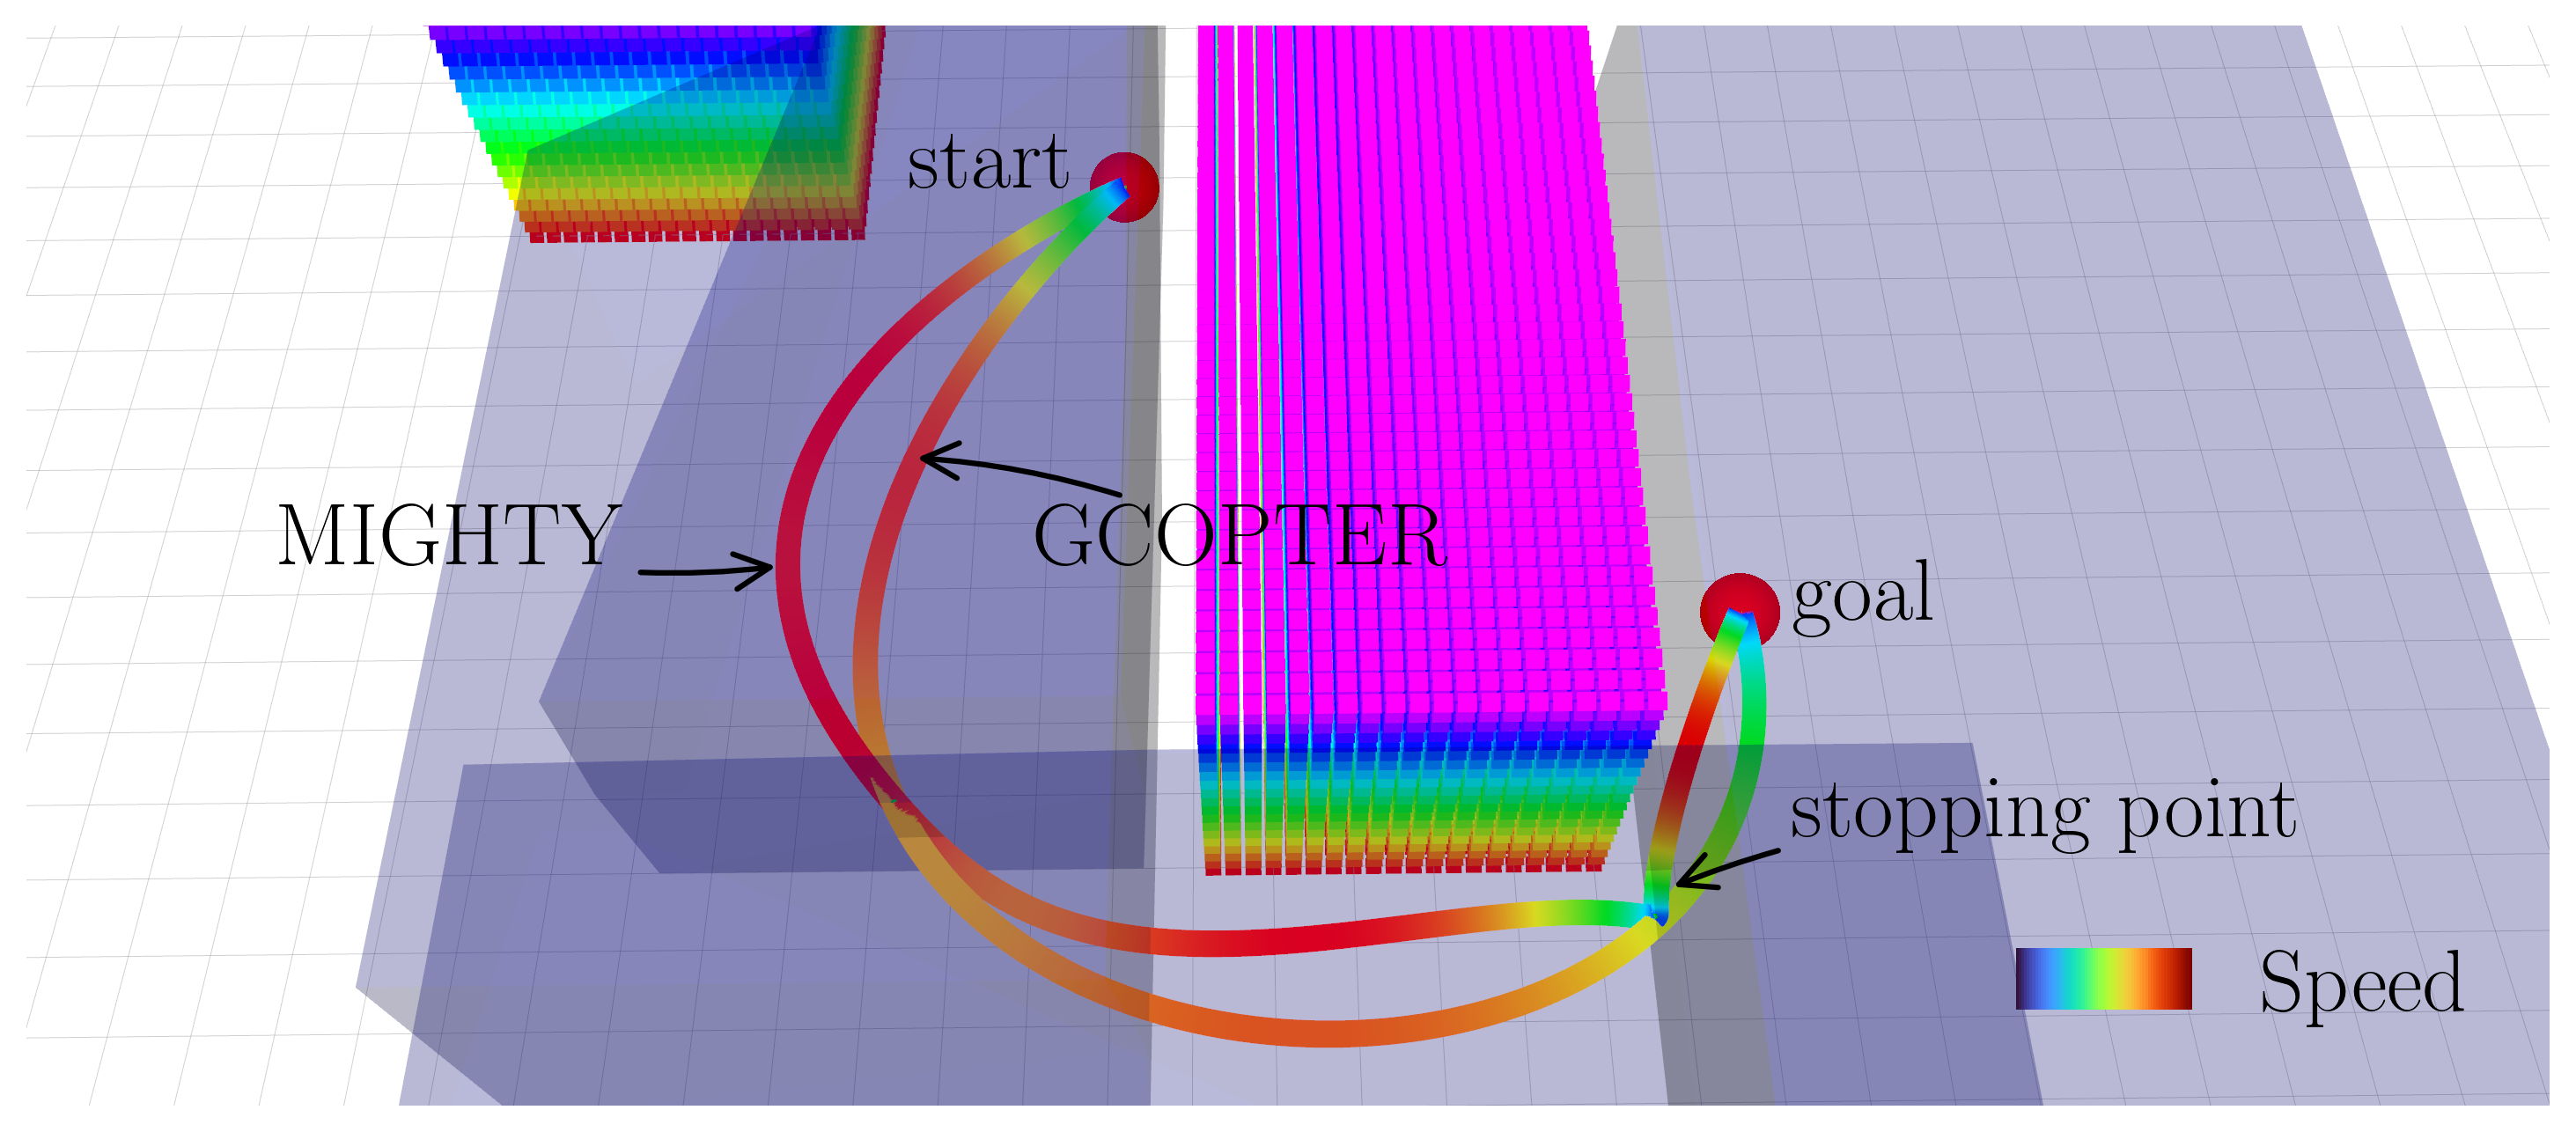

In [45]:
# Annotate the ref_pos_vel_results screenshot with labels
# Using same horizontal gradient legend style as analyze_data.ipynb

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
from matplotlib.legend_handler import HandlerBase

class _GradientLegend:
    """A dummy handle that carries a colormap + orientation for the legend."""
    def __init__(self, cmap='turbo', orientation='horizontal', n=64):
        self.cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
        self.orientation = orientation
        self.n = int(n)

class _HandlerGradient(HandlerBase):
    """Draws a gradient rectangle inside the legend handle box."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        n = max(2, orig_handle.n)
        cmap = orig_handle.cmap
        orient = orig_handle.orientation
        artists = []
        if orient == 'horizontal':
            w = width / n
            for i in range(n):
                color = cmap(i / (n - 1))
                artists.append(Rectangle((xdescent + i * w, ydescent),
                                         w, height, transform=trans,
                                         facecolor=color, edgecolor='none'))
        else:
            h = height / n
            for i in range(n):
                color = cmap(i / (n - 1))
                artists.append(Rectangle((xdescent, ydescent + i * h),
                                         width, h, transform=trans,
                                         facecolor=color, edgecolor='none'))
        return artists

img_path = "/home/kkondo/Pictures/Screenshots/ref_pos_vel_results.png"
out_path = "/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/ref_bench/paper_ready_ref_pos_vel.png"

# Load image
im = Image.open(img_path).convert("RGBA")
arr = np.asarray(im)
H, W = arr.shape[:2]

# Crop: (left, bottom, right, top) pixels to remove from each side
cut = (100, 150, 100, 200)  # Adjust these values as needed
left, bottom, right, top = cut
cropped = arr[top:H-bottom, left:W-right]
ch, cw = cropped.shape[:2]

# Create figure
dpi = 300
fig, ax = plt.subplots(figsize=(cw/dpi, ch/dpi), dpi=dpi)
ax.imshow(cropped)
ax.axis("off")

# ============ SINGLE FONTSIZE FOR ALL LABELS ============
FONTSIZE = 24  # Change this one value to adjust all text sizes

# Arrow style
arrow_props = dict(
    arrowstyle='->', 
    color='black', 
    lw=1.5,
    connectionstyle='arc3,rad=0.1'
)

# Common text style
text_style = dict(fontsize=FONTSIZE, fontweight='bold', color='black')

# Labels without arrows (start, goal)
ax.text(0.35, 0.85, "start", transform=ax.transAxes, **text_style)
ax.text(0.7, 0.45, "goal", transform=ax.transAxes, **text_style)

# Labels WITH arrows (GCOPTER, MIGHTY, stopping point)
ax.annotate("GCOPTER", 
            xy=(0.35, 0.60), xytext=(0.4, 0.5),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=arrow_props, **text_style)

ax.annotate("MIGHTY", 
            xy=(0.3, 0.5), xytext=(0.10, 0.5),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=arrow_props, **text_style)

ax.annotate("stopping point", 
            xy=(0.65, 0.20), xytext=(0.70, 0.25),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=arrow_props, **text_style)

# Speed legend with horizontal rainbow gradient
h = _GradientLegend(cmap="turbo", orientation="horizontal", n=64)
leg = ax.legend([h], ["Speed"], loc="lower right", frameon=False, fontsize=FONTSIZE,
                handler_map={_GradientLegend: _HandlerGradient()})

fig.tight_layout(pad=0)
fig.savefig(out_path, dpi=dpi, bbox_inches='tight', pad_inches=0)
print(f"Saved: {out_path} (cropped from {W}x{H} to {cw}x{ch})")
plt.show()